In [ ]:
# Data handling
import itertools
import pandas as pd
import numpy as np
from tqdm import tqdm

# Machine Learning
import seaborn as sns
import sklearn
from sklearn.metrics import matthews_corrcoef
import scipy as sp
import scipy.spatial.distance as sp_dist
import umap

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Chemistry related packages
import deepchem as dc
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import descriptastorus
from descriptastorus.descriptors import rdNormalizedDescriptors

c:\Users\erinw\AnacondaInstall\envs\1148\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers depend

#### Dataset Loading
In this step, the DeepChem library was used to load the whole dataset, where smiles were canonicalised during the loading process. The predefined training, validation, and test sets were merged into a single dataframe, where each molecule contain the respective SMILES and toxicity labels.

In [ ]:
tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer="Raw", reload=False
)
train, valid, test = datasets
all_datasets = [train, valid, test]
all_smiles = []
all_labels = []
for dataset in all_datasets:
    all_smiles.extend(dataset.ids)
    all_labels.extend(dataset.y)

df = pd.DataFrame(all_smiles, columns=['SMILES'])
df[tasks] = all_labels

print(f"Total molecules: {len(df)}")
print(df.head())

[14:39:02] WARNING: not removing hydrogen atom without neighbors
[14:39:02] Explicit valence for atom # 8 Al, 6, is greater than permitted
Failed to featurize datapoint 1322, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
[14:39:02] Explicit valence for atom # 3 Al, 6, is greater than permitted
Failed to featurize datapoint 2290, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
[14:39:02] Explicit valence for ato

Total molecules: 7823
                                     SMILES  NR-AR  NR-AR-LBD  NR-AhR  \
0                 CC(O)(P(=O)(O)O)P(=O)(O)O    0.0        0.0     0.0   
1      CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C    0.0        0.0     0.0   
2             OC[C@H](O)[C@@H](O)[C@H](O)CO    0.0        0.0     0.0   
3  CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2]    0.0        0.0     0.0   
4                         CC(C)COC(=O)C(C)C    0.0        0.0     0.0   

   NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  SR-ARE  SR-ATAD5  SR-HSE  \
0           0.0    0.0        0.0            0.0     0.0       0.0     0.0   
1           0.0    0.0        0.0            0.0     0.0       0.0     0.0   
2           0.0    0.0        0.0            0.0     0.0       0.0     0.0   
3           0.0    0.0        0.0            0.0     0.0       0.0     0.0   
4           0.0    0.0        0.0            0.0     0.0       0.0     0.0   

   SR-MMP  SR-p53  
0     0.0     0.0  
1     0.0     0.0  
2     0.0 

In [ ]:
# Check on invalid or duplicated smiles

def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None

df_original = df.copy()
print(f"Total molecules: {len(df_original)}")
df_original['canonical_smiles'] = df_original['SMILES'].apply(canonicalize)
invalid_count = df_original['canonical_smiles'].isna().sum()
print(f"Invalid SMILES found: {invalid_count}")
duplicate_count = df_original.duplicated(subset=['canonical_smiles']).sum()
print(f"Duplicate molecules found: {duplicate_count}")

df_clean = df_original.dropna(subset=['canonical_smiles']).copy()
df_clean.drop_duplicates(
    subset=["canonical_smiles"], keep="first", inplace=True
)
print(f"Unique molecules after cleaning: {len(df_clean)}")

df_processed = df_clean.drop(columns=['SMILES']).copy()
df_processed.columns

Total molecules: 7823


[14:39:05] WARNING: not removing hydrogen atom without neighbors


Invalid SMILES found: 0
Duplicate molecules found: 0
Unique molecules after cleaning: 7823


Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
       'canonical_smiles'],
      dtype='str')

#### Section 3: EDA 
The dataset was first evaluted for missing toxicity labels. No missing labels were identified.

In [ ]:
# Checking Missing Labels

task_cols = [c for c in df.columns if c != "SMILES"]
missing_rows_count = df[task_cols].isna().any(axis=1).sum()
total_rows = len(df)

print(f"Total molecules: {total_rows}")
print(f"Molecules with at least one missing task: {missing_rows_count}")

# Wrapped to securely respect the 79-character limit
print(
    f"Percentage of incomplete rows: "
    f"{(missing_rows_count / total_rows) * 100:.2f}%"
)

Total molecules: 7823
Molecules with at least one missing task: 0
Percentage of incomplete rows: 0.00%


The distribution of the active (1.0) and negative (0.0) toxicity labels were quantified across all toxicity tasks. The stacked bar chart was being used to visualize the class imbalnce.

               Positive (1)  Negative (0)  % Positive
NR-PPAR-gamma         186.0          7637    2.377604
NR-AR-LBD             237.0          7586    3.029528
SR-ATAD5              264.0          7559    3.374664
NR-Aromatase          300.0          7523    3.834846
NR-AR                 308.0          7515    3.937109
NR-ER-LBD             349.0          7474    4.461204
SR-HSE                372.0          7451    4.755209
SR-p53                423.0          7400    5.407133
NR-AhR                768.0          7055    9.817206
NR-ER                 791.0          7032   10.111211
SR-MMP                918.0          6905   11.734629
SR-ARE                942.0          6881   12.041416


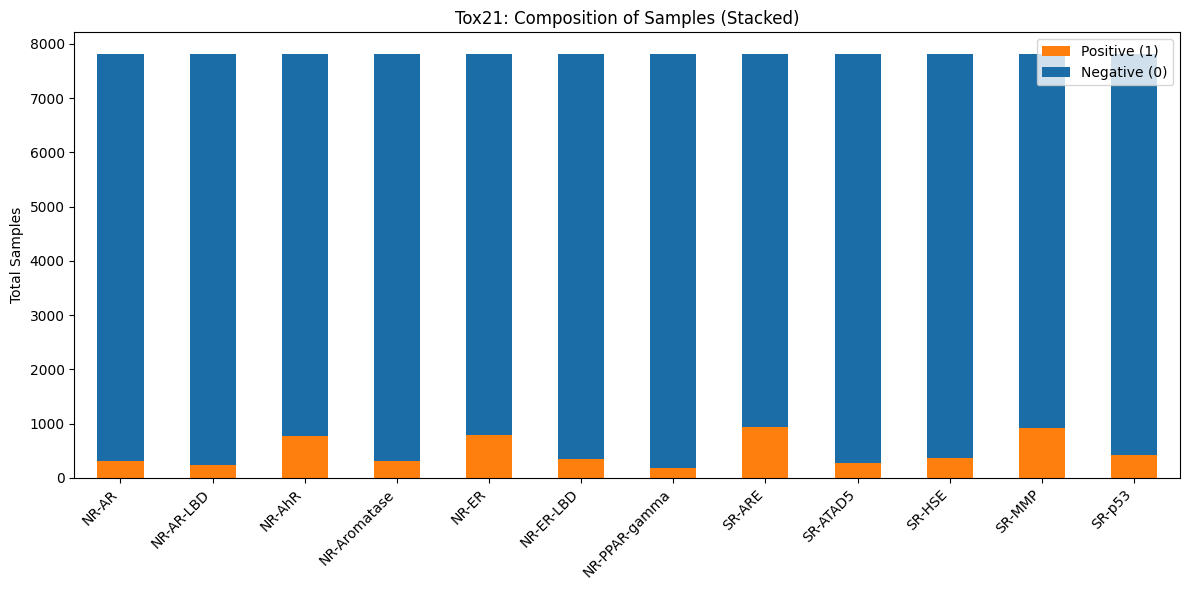

In [ ]:
# Class Imbalance

task_cols = [c for c in df.columns if c != 'SMILES']
imbalance_df = pd.DataFrame({
    'Positive (1)': df[task_cols].sum(),
    'Negative (0)': (df[task_cols] == 0).sum()
})
imbalance_df["% Positive"] = (
    imbalance_df["Positive (1)"] / 
    (imbalance_df["Positive (1)"] + imbalance_df["Negative (0)"])
) * 100
print(imbalance_df.sort_values(by='% Positive'))

imbalance_df[['Positive (1)', 'Negative (0)']].plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    color=['#ff7f0e', "#1b6da8"]
)
plt.title('Tox21: Composition of Samples (Stacked)')
plt.ylabel('Total Samples')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Matthews correlation coefficient was calculated to quantify the relationship between the toxicity labels, which was also visulised in form of heatmap.

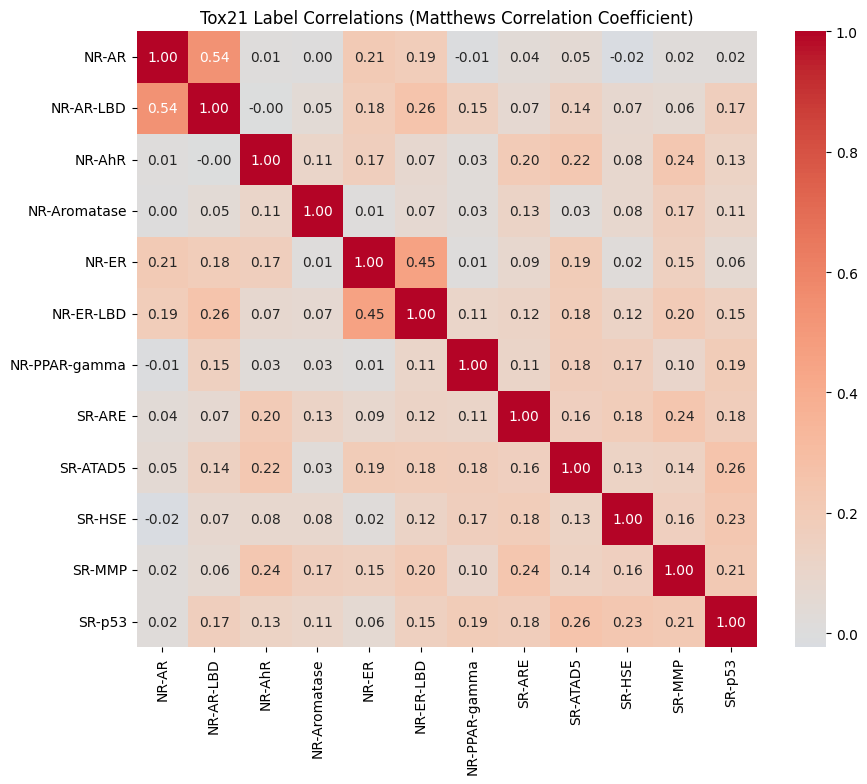

In [ ]:
# Label correlations (Matthews Correlation)

task_cols = [c for c in df.columns if c not in ['SMILES']]
mcc_matrix = pd.DataFrame(index=task_cols, columns=task_cols, dtype=float)

for col1 in task_cols:
    for col2 in task_cols:
        mask = df[col1].notna() & df[col2].notna()
        y_true = df.loc[mask, col1]
        y_pred = df.loc[mask, col2]
        
        if len(y_true) > 0:
            mcc_matrix.loc[col1, col2] = matthews_corrcoef(
                y_true, y_pred
            )
        else:
            mcc_matrix.loc[col1, col2] = np.nan

plt.figure(figsize=(10, 8))
sns.heatmap(mcc_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0
)
plt.title("Tox21 Label Correlations (Matthews Correlation Coefficient)")
plt.show()

Some key molecular descriptors, including molecular weight, LogP, and hyrdrogen bond capacity, were calculated to characterise the statistics and provide an overview of the dataset.

In [ ]:
# smile statistics

def get_smiles_stats(mol):
    if mol:
        return pd.Series({
            "Molecular Weight": Descriptors.MolWt(mol),
            "LogP": Descriptors.MolLogP(mol),
            "Hydrogen Bond Donor": Descriptors.NumHDonors(mol),
            "Hydrogen Bond Acceptor": Descriptors.NumHAcceptors(mol),
            "Heavy Atoms": Descriptors.HeavyAtomCount(mol)
        })
    else:
        return pd.Series([np.nan] * 5)


stats_df = df["SMILES"].apply(
    lambda x: get_smiles_stats(Chem.MolFromSmiles(x))
)

df = pd.concat([df, stats_df], axis=1)

print(
    df[
        [
            "Molecular Weight",
            "LogP",
            "Hydrogen Bond Donor",
            "Hydrogen Bond Acceptor",
            "Heavy Atoms",
        ]
    ].describe()
)

[14:39:06] WARNING: not removing hydrogen atom without neighbors


       Molecular Weight         LogP  Hydrogen Bond Donor  \
count       7823.000000  7823.000000          7823.000000   
mean         276.144155     2.373943             1.224978   
std          164.732356     2.304307             1.916035   
min            9.012000   -17.406400             0.000000   
25%          165.236000     1.149350             0.000000   
50%          240.302000     2.365500             1.000000   
75%          343.044000     3.653150             2.000000   
max         1877.664000    22.611800            30.000000   

       Hydrogen Bond Acceptor  Heavy Atoms  
count             7823.000000  7823.000000  
mean                 3.473987    18.566918  
std                  3.115448    11.309542  
min                  0.000000     1.000000  
25%                  2.000000    11.000000  
50%                  3.000000    16.000000  
75%                  4.000000    23.000000  
max                 46.000000   132.000000  


Morgan fingerprints were generated and pairwise Tanimoto coefficients were calculated to quantify the structural diversity of dataset. The similarity distribution was also visualised.

[14:39:09] WARNING: not removing hydrogen atom without neighbors


Mean Tanimoto Similarity: 0.0877


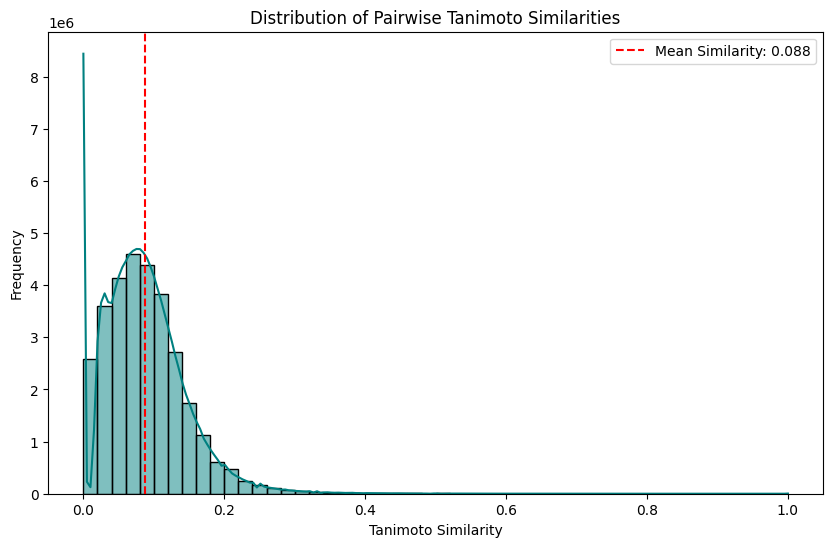

In [ ]:
# Morgan similarity and dataset diversity

morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)
fps = []

for s in df["SMILES"]:
    mol = Chem.MolFromSmiles(s)
    if mol is not None:
        fp = morgan_gen.GetFingerprint(mol)
        fps.append(fp)

similarities = []

for i in range(len(fps)):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:])
    similarities.extend(sims)

mean_sim = np.mean(similarities)
print(f"Mean Tanimoto Similarity: {mean_sim:.4f}")

plt.figure(figsize=(10, 6))

sns.histplot(
    similarities,
    bins=50,
    kde=True,
    color="teal"
)

plt.axvline(
    mean_sim,
    color="red",
    linestyle="--",
    label=f"Mean Similarity: {mean_sim:.3f}"
)

plt.title("Distribution of Pairwise Tanimoto Similarities")
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

A comprehensive set of 200 normalized 2D RDKit descriptors were generated using the descriptastorus library. 4 out of 200 features with NaN values were removed. A pairwise cosine distance matrix and corresponding distribution plot were then constructed to evaluate the chemical diversity of the dataset.

In [ ]:
# Feature similarity and dataset diversity

generator = rdNormalizedDescriptors.RDKit2DNormalized()
features = []

for s in df["SMILES"]:
    mol = Chem.MolFromSmiles(s)
    if mol is not None:
        res = generator.calculateMol(mol, None)
        if res is not None:
            features.append(res)

x = np.array(features)
print(f"Matrix x shape: {x.shape}")

nan_count = np.isnan(x).sum()
print(f"Total NaN values found: {nan_count}")

nan_cols = np.where(np.isnan(x).any(axis=0))[0]
print(f"Number of columns containing NaNs: {len(nan_cols)}")

[14:40:03] WARNING: not removing hydrogen atom without neighbors
[14:40:03] WARNING: not removing hydrogen atom without neighbors


Matrix x shape: (7823, 200)
Total NaN values found: 372
Number of columns containing NaNs: 4


In [ ]:
# Remove columns with NaN values and print the names of the removed descriptors

descriptor_names = [col[0] for col in generator.columns]
nan_col_indices = np.where(np.isnan(x).any(axis=0))[0]
problematic_descriptors = [descriptor_names[i] for i in nan_col_indices]
print(f"Problematic columns: {problematic_descriptors}")

all_col_indices = np.arange(x.shape[1])
clean_col_indices = np.delete(all_col_indices, nan_col_indices)
x_filtered = x[:, clean_col_indices]

print(f"Original matrix shape: {x.shape}")
print(f"Filtered matrix shape: {x_filtered.shape}")

Problematic columns: ['MaxAbsPartialCharge', 'MaxPartialCharge', 'MinAbsPartialCharge', 'MinPartialCharge']
Original matrix shape: (7823, 200)
Filtered matrix shape: (7823, 196)


100%|██████████| 30595753/30595753 [02:37<00:00, 193754.09it/s]


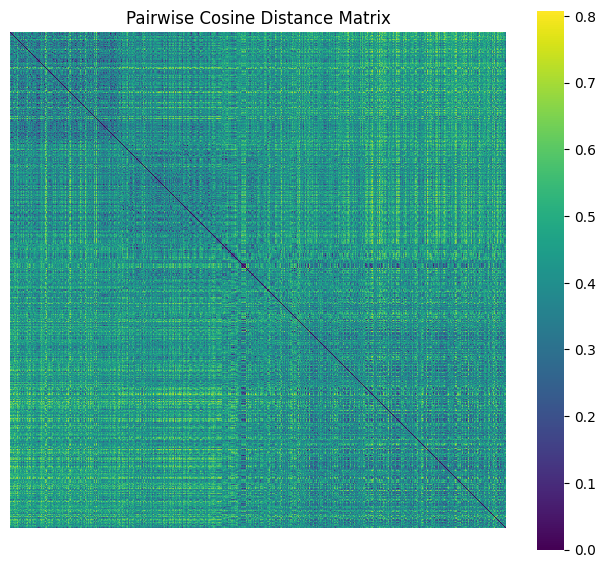

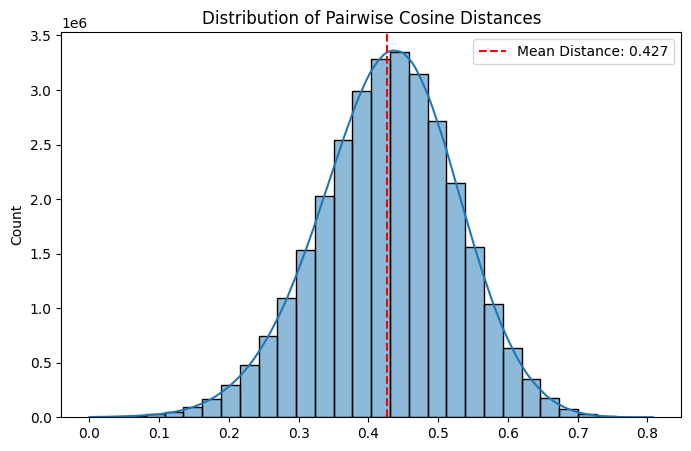

Median Cosine Distance: 0.4305
Mean Cosine Distance: 0.4272
Standard Deviation: 0.0993


In [ ]:
# Pairwise cosine distance matrix and distribution plot were plotted.

n = x_filtered.shape[0]
distance_matrix = np.zeros((n, n))
pbar = tqdm(itertools.combinations(range(n), 2), total=n * (n - 1) // 2)

for (i, j) in pbar:
    d = sp_dist.cosine(x_filtered[i], x_filtered[j])
    distance_matrix[i, j] = distance_matrix[j, i] = d

plt.figure(figsize=(8, 7))

# Fixed hanging indents to standard 4-spaces
sns.heatmap(
    distance_matrix,
    cmap="viridis",
    square=True,
    xticklabels=False,
    yticklabels=False
)

plt.title("Pairwise Cosine Distance Matrix")
plt.show()

distances = distance_matrix[np.triu_indices_from(distance_matrix, k=1)]
median_dist = np.percentile(distances, 50)
mean_dist = np.mean(distances)
std_dist = np.std(distances)

plt.figure(figsize=(8, 5))

sns.histplot(
    distances,
    bins=30,
    kde=True
)

plt.axvline(
    mean_dist,
    color="red",
    linestyle="--",
    label=f"Mean Distance: {mean_dist:.3f}"
)

plt.title("Distribution of Pairwise Cosine Distances")
plt.legend()
plt.show()

print(f"Median Cosine Distance: {median_dist:.4f}")
print(f"Mean Cosine Distance: {mean_dist:.4f}")
print(f"Standard Deviation: {std_dist:.4f}")

PCA and UMAP were used to project high-dimensional molecular features or the toxicity labels into a 2D plane for visualization. 

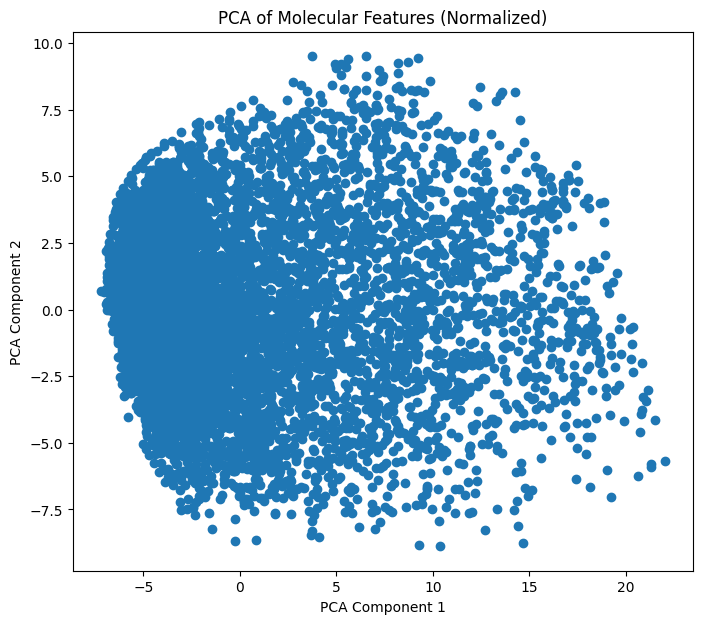

In [ ]:
# pca visualization on the molecular features of the dataset

pca_pipeline = sklearn.pipeline.Pipeline([
    ("scaler", sklearn.preprocessing.StandardScaler()),
    ("pca", sklearn.decomposition.PCA(n_components=2))
])

pca_components = pca_pipeline.fit_transform(x_filtered)

plt.figure(figsize=(8, 7))
plt.scatter(pca_components[:, 0], pca_components[:, 1])

plt.title("PCA of Molecular Features (Normalized)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

c:\Users\erinw\AnacondaInstall\envs\1148\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


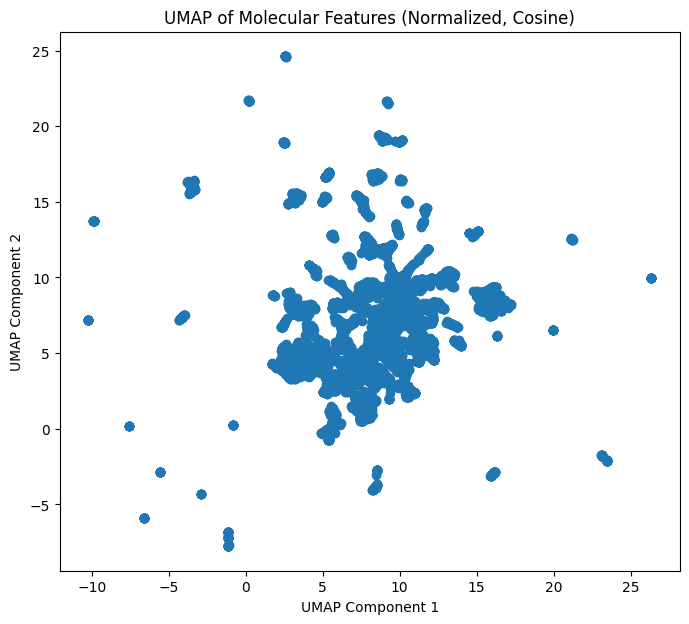

In [ ]:
# umap visualization on the molecular features of the dataset

umap_pipeline = sklearn.pipeline.Pipeline([
    ("scaler", sklearn.preprocessing.StandardScaler()),
    ("umap", umap.UMAP(n_components=2, metric="cosine", random_state=42))
])

umap_components = umap_pipeline.fit_transform(x_filtered)

plt.figure(figsize=(8, 7))
plt.scatter(umap_components[:, 0], umap_components[:, 1])

plt.title("UMAP of Molecular Features (Normalized, Cosine)")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.tight_layout()
plt.show()

c:\Users\erinw\AnacondaInstall\envs\1148\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\erinw\AnacondaInstall\envs\1148\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Number of clusters found by HDBSCAN: 14


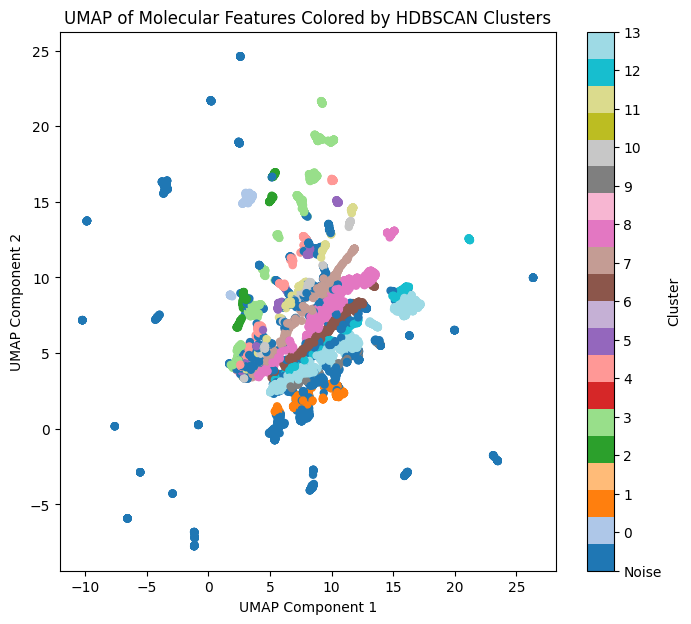

In [ ]:
# hdbscan clustering on umap components of the molecular features of the dataset

hdbscan_clusterer = sklearn.cluster.HDBSCAN(
    metric="cosine", min_cluster_size=120
)

umap_pipeline = sklearn.pipeline.Pipeline([
    ("scaler", sklearn.preprocessing.StandardScaler()),
    ("umap", umap.UMAP(n_components=2, metric="cosine", random_state=42))
])

umap_components = umap_pipeline.fit_transform(x_filtered)
clusters = hdbscan_clusterer.fit_predict(umap_components)

unique_clusters = np.unique(clusters)
num_clusters = len(unique_clusters[unique_clusters != -1])
print(f"Number of clusters found by HDBSCAN: {num_clusters}")

plt.figure(figsize=(8, 7))

# Wrapped to securely respect the 79-character limit
scatter = plt.scatter(
    umap_components[:, 0], 
    umap_components[:, 1], 
    c=clusters, 
    cmap="tab20", 
    s=25
)

plt.title("UMAP of Molecular Features Colored by HDBSCAN Clusters")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

colorbar = plt.colorbar(scatter, ticks=unique_clusters)
colorbar.set_label("Cluster")

# Wrapped list comprehension to stay under 79 characters
colorbar.ax.set_yticklabels(
    [int(c) if c != -1 else "Noise" for c in unique_clusters]
)

plt.tight_layout()
plt.show()

c:\Users\erinw\AnacondaInstall\envs\1148\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
c:\Users\erinw\AnacondaInstall\envs\1148\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


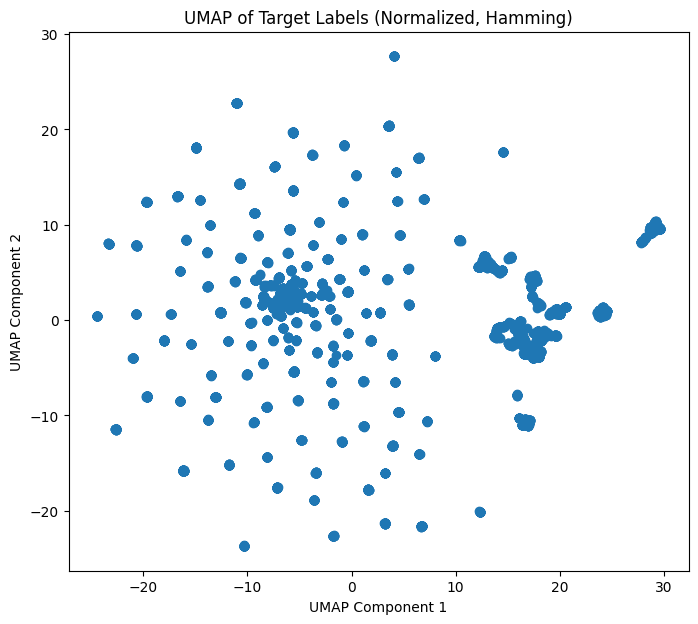

In [ ]:
# umap visualization on the target labels of the dataset

target_columns = df.columns[1:13]
y_matrix = df[target_columns].values

umap_model = umap.UMAP(
    n_components=2,
    metric="hamming",
    random_state=42
)

umap_components = umap_model.fit_transform(y_matrix)

plt.figure(figsize=(8, 7))
plt.scatter(umap_components[:, 0], umap_components[:, 1])

plt.title("UMAP of Target Labels (Normalized, Hamming)")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.tight_layout()
plt.show()

c:\Users\erinw\AnacondaInstall\envs\1148\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


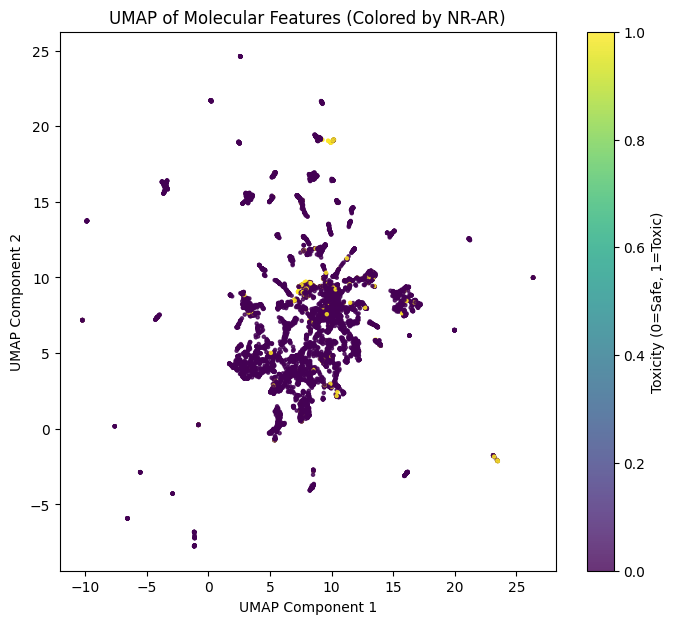

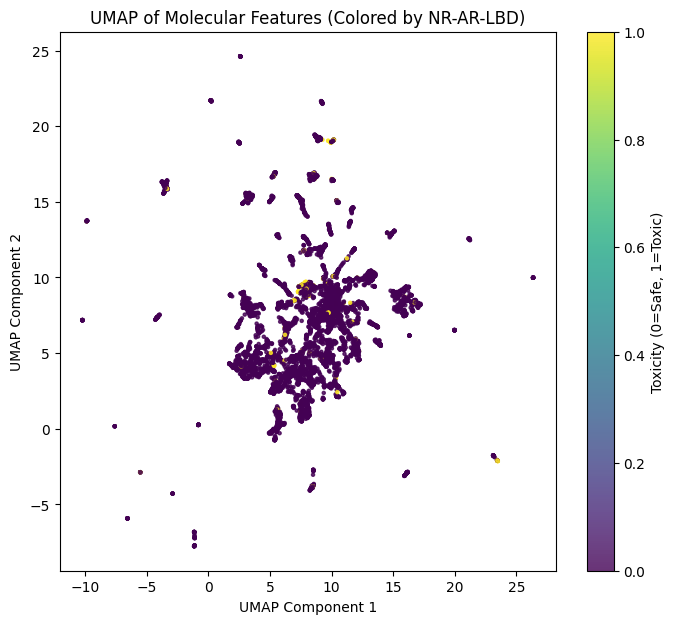

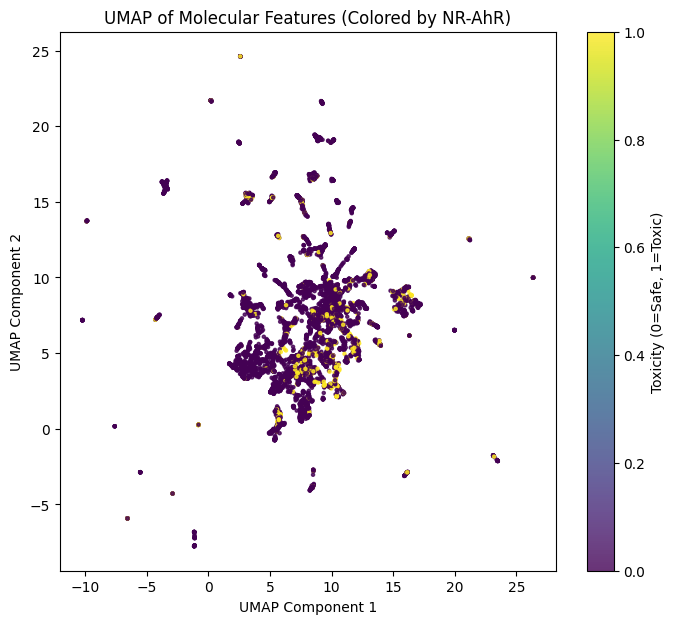

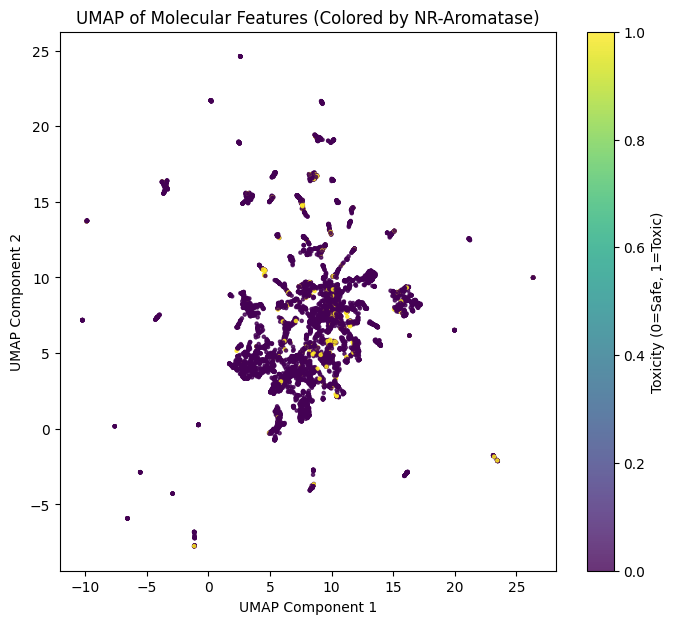

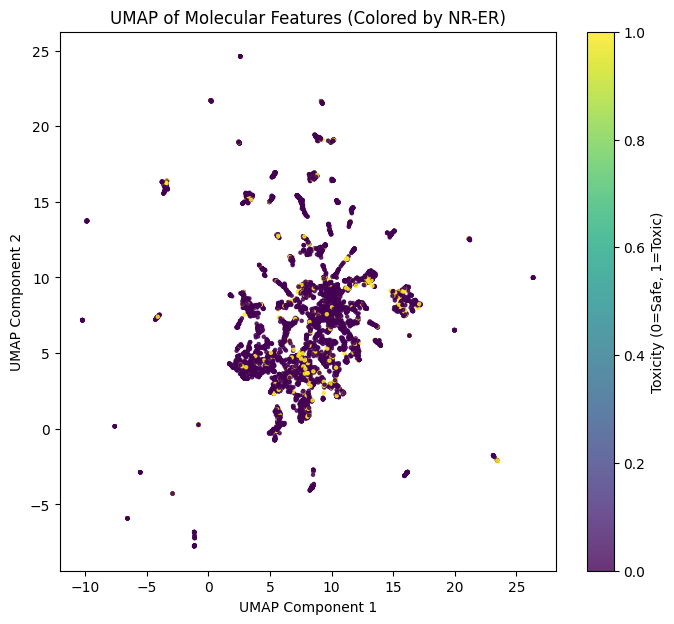

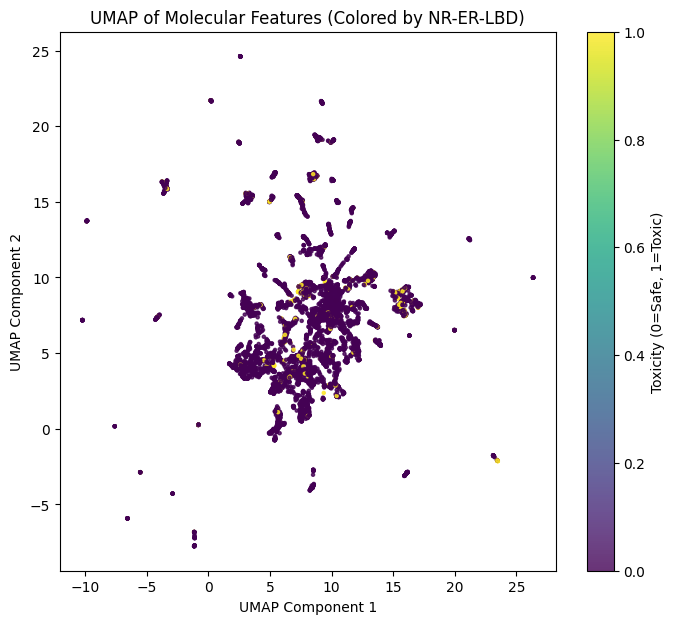

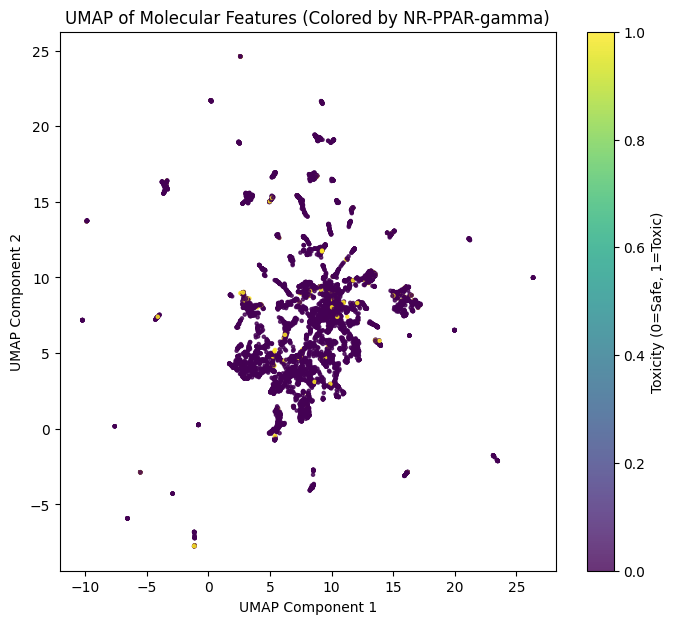

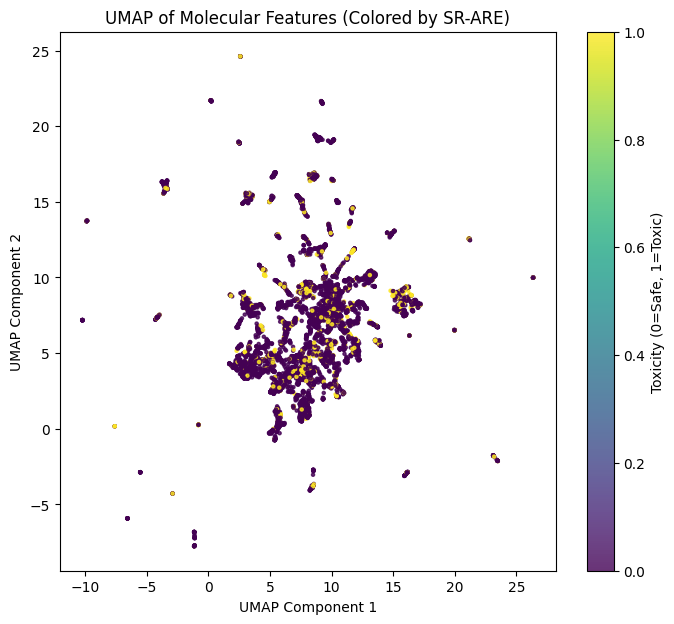

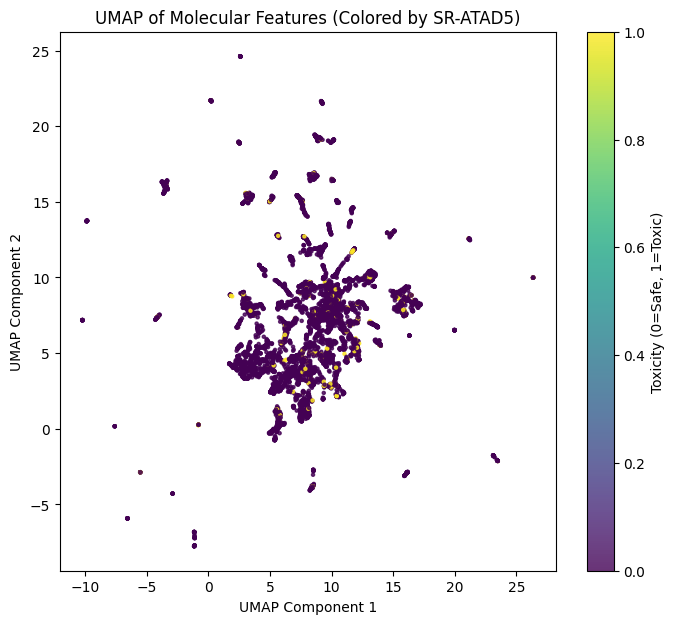

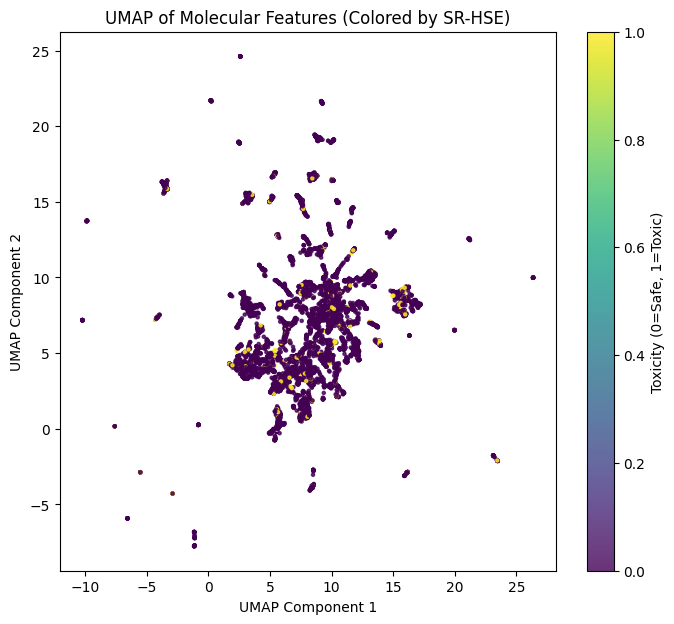

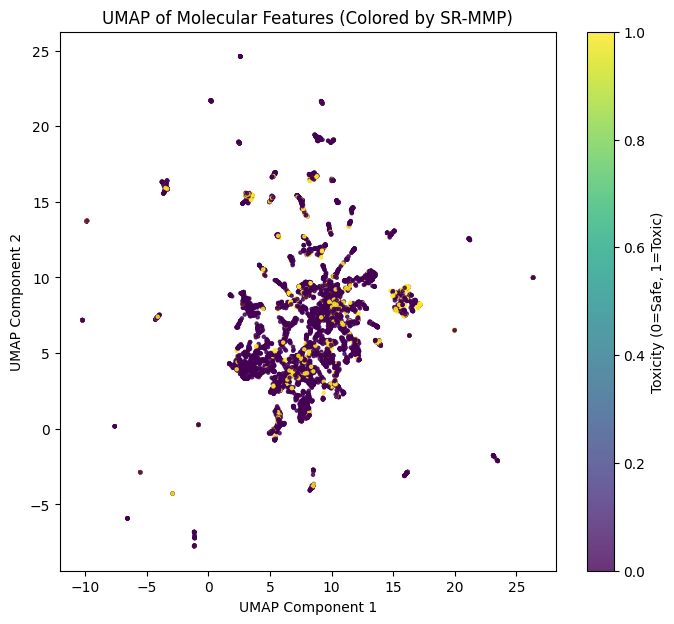

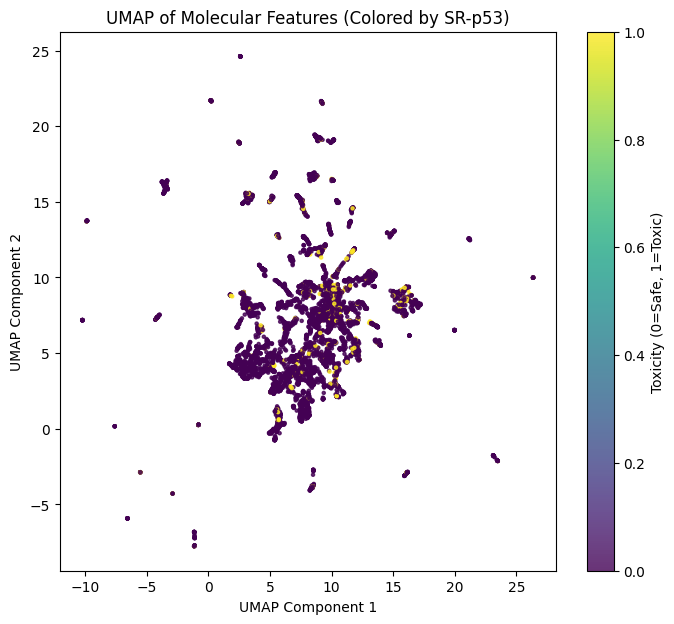

In [ ]:
# umap visualization on molecular features colored by the target labels

umap_pipeline = sklearn.pipeline.Pipeline([
    ("scaler", sklearn.preprocessing.StandardScaler()),
    ("umap", umap.UMAP(n_components=2, metric="cosine", random_state=42))
])

umap_components = umap_pipeline.fit_transform(x_filtered)

for i, target_name in enumerate(target_columns):
    plt.figure(figsize=(8, 7))
    
    # Fixed the misaligned closing parenthesis
    scatter = plt.scatter(
        umap_components[:, 0],
        umap_components[:, 1], 
        c=y_matrix[:, i],
        cmap="viridis",
        s=5,
        alpha=0.8
    )
    
    plt.title(f"UMAP of Molecular Features (Colored by {target_name})")
    plt.xlabel("UMAP Component 1")
    plt.ylabel("UMAP Component 2")
    plt.colorbar(scatter, label="Toxicity (0=Safe, 1=Toxic)")
    
    plt.tight_layout()
    plt.show()